In [16]:
from pathlib import Path
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import get_dataset_root, CLASS_MAPPING, LABEL_NAMES

# Dataset path from .env or environment
DATASET_ROOT = get_dataset_root()

# Allowed image formats
VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT.resolve())
print("Dataset exists:", DATASET_ROOT.exists())

Project root: D:\dev\forged-stamp-recognizer
Dataset root: D:\sem-07\EC-7205-computer-vision-image-processing\CA\project\final_dataset
Dataset exists: True


In [17]:
dataset_records = []

for class_folder, label in CLASS_MAPPING.items():
    folder_path = DATASET_ROOT / class_folder
    
    if not folder_path.exists():
        print(f"WARNING: Missing folder: {folder_path}")
        continue
    
    for file_path in folder_path.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
            dataset_records.append({
                "file_path": str(file_path),
                "file_name": file_path.name,
                "class_folder": class_folder,
                "label": label,
                "class_name": LABEL_NAMES[label],
                "extension": file_path.suffix.lower()
            })

df_dataset = pd.DataFrame(dataset_records)

print("Total valid image files found:", len(df_dataset))
df_dataset.head()

Total valid image files found: 540


,file_path,file_name,class_folder,label,class_name,extension
0,D:\sem-07\EC-7205-computer-vision-image-proces...,Gen_A_300dpi_001.png,class_0_genuine,0,genuine,.png
1,D:\sem-07\EC-7205-computer-vision-image-proces...,Gen_A_300dpi_002.png,class_0_genuine,0,genuine,.png
2,D:\sem-07\EC-7205-computer-vision-image-proces...,Gen_A_300dpi_003.png,class_0_genuine,0,genuine,.png
3,D:\sem-07\EC-7205-computer-vision-image-proces...,Gen_A_300dpi_004.png,class_0_genuine,0,genuine,.png
4,D:\sem-07\EC-7205-computer-vision-image-proces...,Gen_A_300dpi_005.png,class_0_genuine,0,genuine,.png


Class distribution:
class_name
forged     214
genuine    326
Name: count, dtype: int64


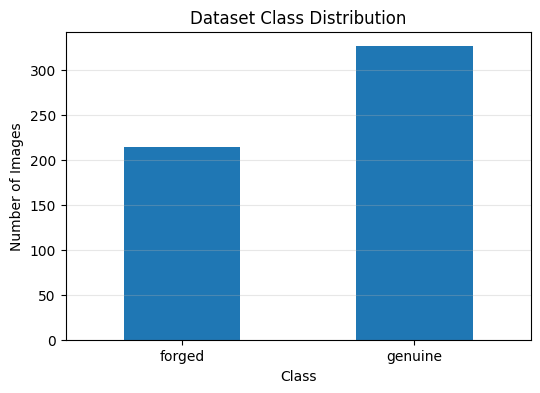

In [18]:
class_counts = df_dataset["class_name"].value_counts().sort_index()

print("Class distribution:")
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [19]:
extension_counts = df_dataset["extension"].value_counts()

print("Image file extension distribution:")
print(extension_counts)

Image file extension distribution:
extension
.png    540
Name: count, dtype: int64


In [20]:
unreadable_files = []
image_metadata = []

for _, row in df_dataset.iterrows():
    image_path = row["file_path"]
    image = cv2.imread(image_path)
    
    if image is None:
        unreadable_files.append(image_path)
        continue
    
    height, width = image.shape[:2]
    channels = image.shape[2] if len(image.shape) == 3 else 1
    
    image_metadata.append({
        "file_path": image_path,
        "file_name": row["file_name"],
        "class_name": row["class_name"],
        "label": row["label"],
        "width": width,
        "height": height,
        "channels": channels,
        "aspect_ratio": width / height if height != 0 else None
    })

df_metadata = pd.DataFrame(image_metadata)

print("Readable images:", len(df_metadata))
print("Unreadable images:", len(unreadable_files))

if unreadable_files:
    print("\nUnreadable file paths:")
    for path in unreadable_files:
        print(path)

Readable images: 540
Unreadable images: 0


In [21]:
print("Image width statistics:")
print(df_metadata["width"].describe())

print("\nImage height statistics:")
print(df_metadata["height"].describe())

print("\nImage channel counts:")
print(df_metadata["channels"].value_counts())

Image width statistics:
count     540.000000
mean     3675.555556
std      1240.798305
min      2481.000000
25%      2481.000000
50%      2481.000000
75%      4962.000000
max      4962.000000
Name: width, dtype: float64

Image height statistics:
count     540.000000
mean     5194.555556
std      1753.921666
min      3506.000000
25%      3506.000000
50%      3506.000000
75%      7013.000000
max      7013.000000
Name: height, dtype: float64

Image channel counts:
channels
3    540
Name: count, dtype: int64


In [22]:
resolution_counts = (
    df_metadata
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Unique image resolutions:")
resolution_counts.head(10)

Unique image resolutions:


,width,height,count
0,2481,3506,280
1,4962,7013,260


In [23]:
def show_samples(df, class_name, n=4, display_width=500):
    class_df = df[df["class_name"] == class_name]

    if len(class_df) == 0:
        print(f"No images found for class: {class_name}")
        return

    sample_df = class_df.sample(
        n=min(n, len(class_df)),
        random_state=42
    )

    plt.figure(figsize=(16, 6))

    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = cv2.imread(row["file_path"])

        if img is None:
            print("Could not read:", row["file_path"])
            continue

        h, w = img.shape[:2]
        scale = display_width / w
        new_h = int(h * scale)

        img_small = cv2.resize(img, (display_width, new_h))
        img_rgb = cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(sample_df), i)
        plt.imshow(img_rgb)
        plt.title(row["file_name"], fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

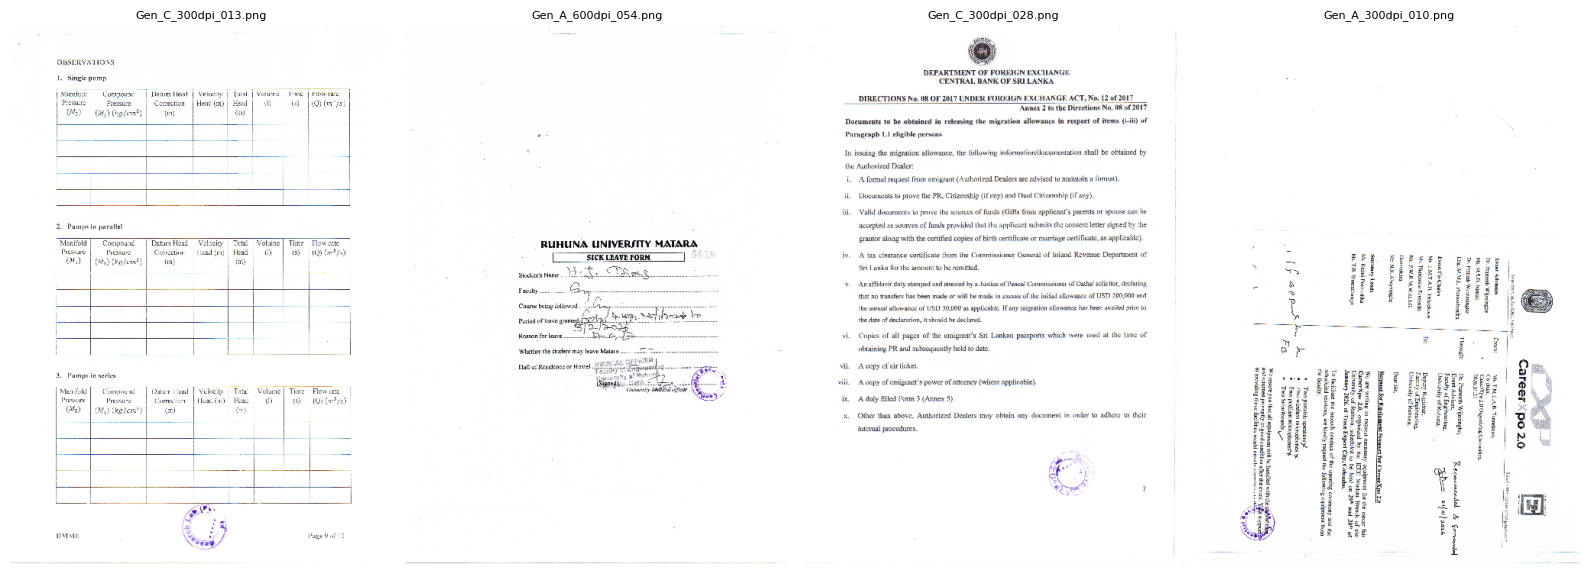

In [24]:
show_samples(df_metadata, "genuine", n=4)

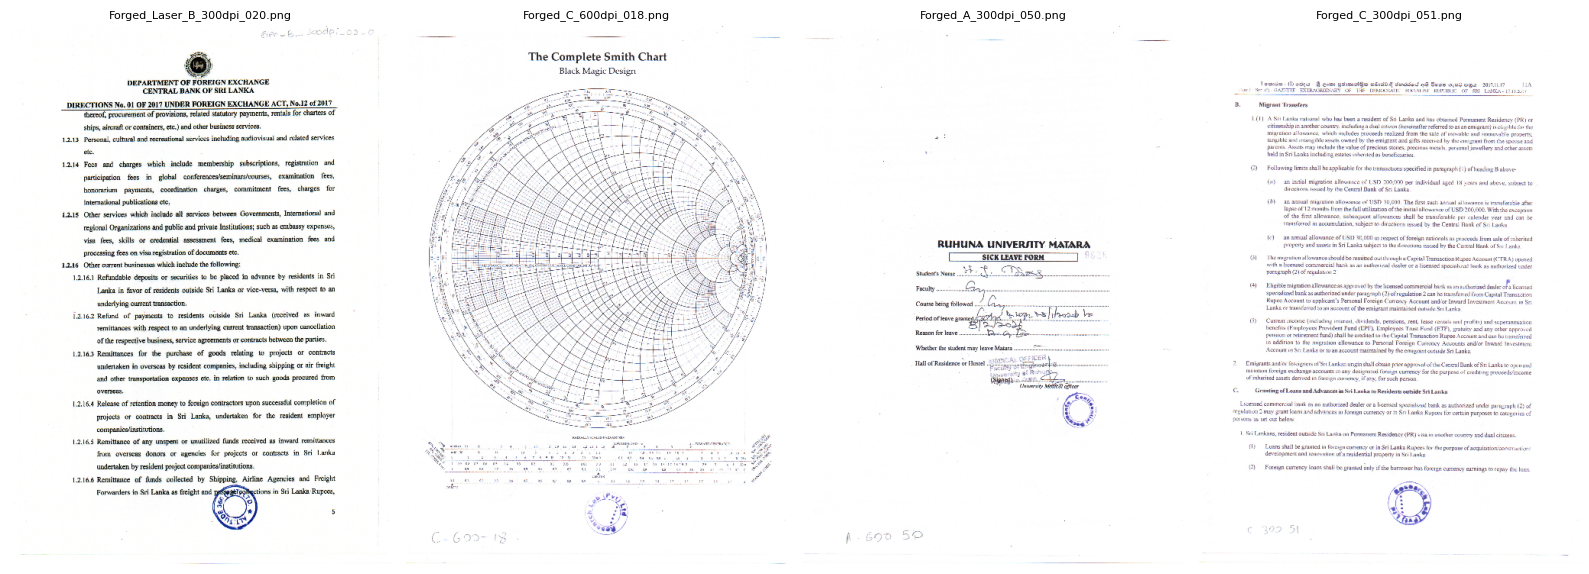

In [25]:
show_samples(df_metadata, "forged", n=4)

In [26]:
OUTPUT_REPORT_DIR = Path("../outputs/reports")
OUTPUT_REPORT_DIR.mkdir(parents=True, exist_ok=True)

dataset_metadata_path = OUTPUT_REPORT_DIR / "dataset_metadata.csv"
df_metadata.to_csv(dataset_metadata_path, index=False)

print("Dataset metadata saved to:")
print(dataset_metadata_path.resolve())

Dataset metadata saved to:
D:\dev\forged-stamp-recognizer\outputs\reports\dataset_metadata.csv


In [27]:
print("=" * 50)
print("DATASET AUDIT SUMMARY")
print("=" * 50)

print(f"Total valid images      : {len(df_dataset)}")
print(f"Readable images         : {len(df_metadata)}")
print(f"Unreadable images       : {len(unreadable_files)}")

print("\nClass distribution:")
print(df_metadata["class_name"].value_counts())

print("\nFile extensions:")
print(df_dataset["extension"].value_counts())

print("\nTop resolutions:")
print(resolution_counts.head())

print("=" * 50)

DATASET AUDIT SUMMARY
Total valid images      : 540
Readable images         : 540
Unreadable images       : 0

Class distribution:
class_name
genuine    326
forged     214
Name: count, dtype: int64

File extensions:
extension
.png    540
Name: count, dtype: int64

Top resolutions:
   width  height  count
0   2481    3506    280
1   4962    7013    260
